### IMPORTACIONES

In [ ]:
import json, ast, joblib, numpy as np, pandas as pd
import os, warnings
from collections import Counter

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV

from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, make_scorer,
    classification_report, confusion_matrix, matthews_corrcoef, roc_curve, auc, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Modelos usados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # Ahora utilizamos n_splits=5 y no 3 porque ya no tenemos el problema de alto coste computacional (nos enfocamos en un solo modelo)

# Scoring múltiple: refit por F1
SCORINGS = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}
REFIT = "f1"


### CARGA DATOS

In [14]:
path = "data/salario.csv"
df = pd.read_csv(path)
df.head(5)

,edad,trabajo,estudios,estado-civil,trabajo.1,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen,salario
0,39,State-gov,Bachelors,Never-married,Adm-clerical,No-en-familia,Blanco,Hombre,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Marido,Blanco,Hombre,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,No-en-familia,Blanco,Hombre,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Marido,Negro,Hombre,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Mujer,Negro,Mujer,0,0,40,Cuba,<=50K


In [15]:
path2 = "data/salario_test.csv"
df_test = pd.read_csv(path2)
df_test.head(5)

,ID,edad,trabajo,estudios,estado-civil,trabajo.1,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen
0,1,36,Private,Assoc-acdm,Never-married,Tech-support,No-en-familia,Blanco,Mujer,0,0,40,United-States
1,2,21,Private,HS-grad,Never-married,Adm-clerical,Otro-familiar,Blanco,Mujer,0,0,45,United-States
2,3,30,Private,HS-grad,Separated,Farming-fishing,Soltero-a,Blanco,Mujer,0,0,14,United-States
3,4,46,Private,Some-college,Married-civ-spouse,Craft-repair,Marido,Blanco,Hombre,0,0,40,United-States
4,5,32,Private,5th-6th,Married-civ-spouse,Machine-op-inspct,Mujer,Asiatico-Pacifico-Isleno,Mujer,0,0,40,Laos


Vamos a trabajar sobre estos 2 archivos csv:

### salario.csv

* Trae *features* + la etiqueta salario (<=50K / >50K).
* Con este archivo:
    * **Limpiamos y ajustamos (*fit*) todo:** imputaciones, One-Hot, escalados;
    * **Entrenamos** el modelo;
    * **Hacemos validación** (*train/test split* interno o CV);
    * **Decidimos** cómo balancear (SMOTE) y qué *features* quedarnos (RFECV, etc.).

---

### salario_test.csv = TEST real

* Trae ID + *features*, **sin** columna salario.
* Con este archivo:
    * Solo transformamos con lo aprendido en salario.csv (mismas columnas, mismo One-Hot/scaler/máscara de RFECV);
    * **No hacemos fit**, no hacemos SMOTE/undersampling;
    * **Predecimos** y generamos el archivo de entrega:
        * ID, salario (con etiquetas de texto usando le.inverse_transform).

---

### LIMPIEZA DE DATOS

In [16]:
# Renombrar columnas (trabajo.1 y trabajo por palabras que describan mejor lo que representa las columnas)
df = df.rename(columns={'trabajo.1': 'sector', 'trabajo': 'tipo_trabajo'})

# Eliminar espacios en blanco en las columnas de tipo 'object'
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# Reemplazar '?' por NaN (no hay valores nulos, sino que aparecen '?' en su lugar)
df = df.replace('?', np.nan)

# Imputación: Usaremos la moda para rellenar los valores perdidos en las columnas categóricas
for col in ['tipo_trabajo', 'sector', 'pais-origen']:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Separar características (X) y variable objetivo (y)
X = df.drop(columns='salario')
y = df['salario']

# Preprocesamiento de la variable objetivo (Label Encoding: <=50K -> 0, >50K -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [17]:
# LIMPIEZA DE DATOS (TEST) 

# Renombrar columnas como en train
df_test = df_test.rename(columns={'trabajo.1': 'sector', 'trabajo': 'tipo_trabajo'})

# Strip de espacios en textos
for col in df_test.select_dtypes(include=['object']).columns:
    df_test[col] = df_test[col].str.strip()

# Reemplazar '?' por NaN
df_test = df_test.replace('?', np.nan)

# Imputar sólo con las modas aprendidas en train 
modes_train = {
    'tipo_trabajo': df['tipo_trabajo'].mode()[0],
    'sector':       df['sector'].mode()[0],
    'pais-origen':  df['pais-origen'].mode()[0],
}
for c, v in modes_train.items():
    if c in df_test.columns:
        df_test[c] = df_test[c].fillna(v)

# Guardar ID y crear X_test (sin la columna ID)
ids_test = df_test['ID'].copy() 
X_test_kaggle = df_test.drop(columns=['ID'])

print("X_test shape:", X_test_kaggle.shape)
X_test_kaggle.head()


X_test shape: (4563, 12)


,edad,tipo_trabajo,estudios,estado-civil,sector,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen
0,36,Private,Assoc-acdm,Never-married,Tech-support,No-en-familia,Blanco,Mujer,0,0,40,United-States
1,21,Private,HS-grad,Never-married,Adm-clerical,Otro-familiar,Blanco,Mujer,0,0,45,United-States
2,30,Private,HS-grad,Separated,Farming-fishing,Soltero-a,Blanco,Mujer,0,0,14,United-States
3,46,Private,Some-college,Married-civ-spouse,Craft-repair,Marido,Blanco,Hombre,0,0,40,United-States
4,32,Private,5th-6th,Married-civ-spouse,Machine-op-inspct,Mujer,Asiatico-Pacifico-Isleno,Mujer,0,0,40,Laos


In [18]:
#df_test no tiene variable objetivo ("salario"), el test solo tiene ID + features; la etiqueta real se guarda para evaluar tus predicciones.
#En test no existe y (no hay nada que codificar (LabelEncoder), entrenar modelos ni con lo que calcular métricas localmente((F1, accuracy) comparando predicción vs. verdad)).
# El LabelEncoder (le) solo se usa para la y del train (mapear <=50K/>50K a  0/1). En test no se hace fit de nada; como máximo usaremos le.inverse_transform para convertir las predicciones (0/1) a etiquetas de texto antes de generar el CSV de envío.

In [19]:
#No podemos calcular métricas locales porque nos falta la “respuesta correcta” para comparar.

#Lo único correcto es transformar con lo aprendido en train y predecir (df_test sirve para predecir con lo aprendido en df: ajustamos (fit) todo con df y 
# solo transformamos df_test, luego realizamos predicciones sobre df_test.)

### PREPROCESAMIENTO (split + Outliers + OHE)

In [21]:
#Split estratificado (NO transformes antes del split)
#Si transformas antes del split introduces fuga de datos (data leakage):
#Los transformadores “aprenden” del conjunto completo. Si haces fit con todo X, usas información del futuro (test) para preparar el entrenamiento.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)



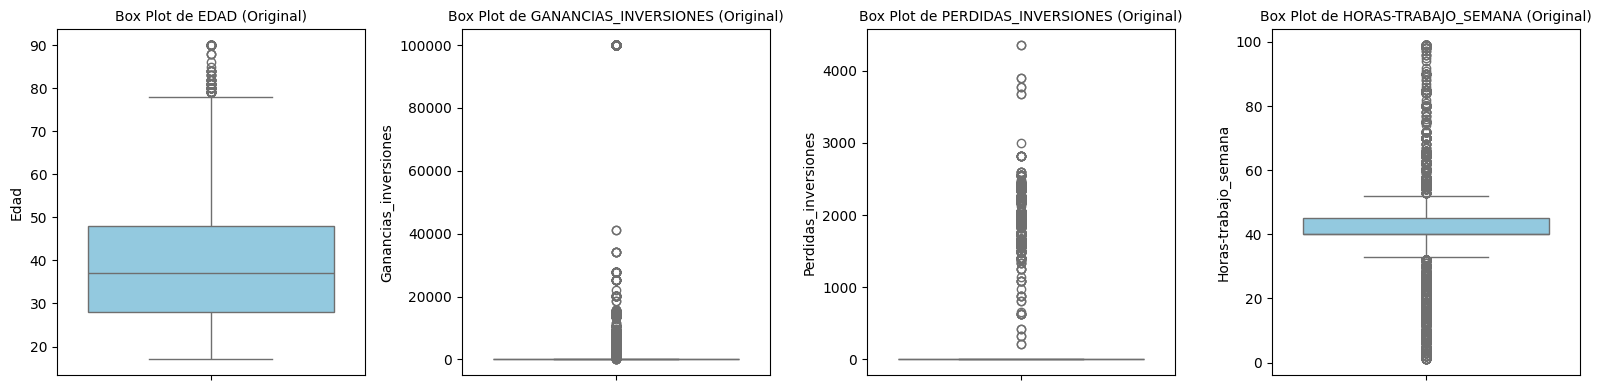

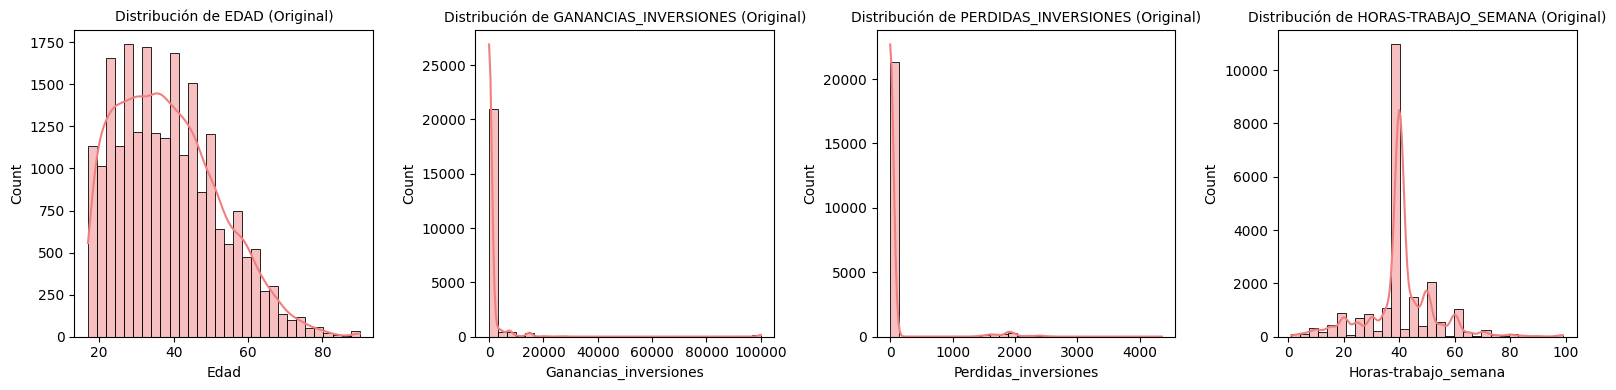

In [ ]:
# VISUALIZACIÓN DE OUTLIERS (Box Plot e Histogramas)

numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Box Plots: Muestran la mediana, cuartiles y los outliers como puntos
plt.figure(figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    # Graficamos el conjunto de entrenamiento antes de tratarlo
    sns.boxplot(y=X_train[col], color='skyblue') 
    plt.title(f'Box Plot de {col.upper()} (Original)', fontsize=10)
    plt.ylabel(col.capitalize())
plt.tight_layout()
plt.show() 

# Histogramas: Muestran la asimetría causada por los valores extremos
plt.figure(figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.histplot(X_train[col], kde=True, bins=30, color='lightcoral')
    plt.title(f'Distribución de {col.upper()} (Original)', fontsize=10)
    plt.xlabel(col.capitalize())
plt.tight_layout()
plt.show() 

In [23]:
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS (Solo en X_train)

# Identificar columnas numéricas (antes de OHE)
numerical_cols_raw = X_train.select_dtypes(include=np.number).columns.tolist()
    
# Definir los cuantiles de corte (p. ej., 5% y 95%)
lower_bound = 0.05
upper_bound = 0.95

for col in numerical_cols_raw:

    # Calcular los límites de los cuantiles en el conjunto de entrenamiento
    q_low = X_train[col].quantile(lower_bound)
    q_high = X_train[col].quantile(upper_bound)
    
    # Winsorización (aplicar los límites de train a train y test)
    # Reemplazar valores de X_train fuera del rango por los límites del cuantil
    X_train[col] = np.where(X_train[col] < q_low, q_low, X_train[col])
    X_train[col] = np.where(X_train[col] > q_high, q_high, X_train[col])
    
    # Aplicar los mismos límites aprendidos en X_train a X_test
    # Esto evita la fuga de datos (data leakage)
    X_test[col] = np.where(X_test[col] < q_low, q_low, X_test[col])
    X_test[col] = np.where(X_test[col] > q_high, q_high, X_test[col])

## Justificación del Tratamiento de Outliers (Winsorización)
Elegimos la Winsorización al 5%-95% en las features numéricas para estabilizar los datos de cara a modelos sensibles como la Regresión Logística.

La Regresión Logística y el escalado son muy sensibles a los valores extremos (outliers), que pueden sesgar gravemente los coeficientes.

Limitamos los valores extremos (del 5% inferior y 5% superior) al valor de sus respectivos cuantiles (5% y 95%). Así, neutralizamos el impacto de los outliers sin eliminar filas de información. Los límites de Winsorización se calculan solo en X_train y luego se aplican a X_test, asegurando una validación justa.

In [24]:
# Columnas numéricas y categóricas
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

# Preprocesador base: solo OHE para categóricas, 'passthrough' para numéricas (todavía no escalamos)
preprocessor_base = ColumnTransformer(
    transformers=[
        # Las numéricas se pasan sin escalar ('passthrough')
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Ajustar solo con TRAIN y transformar TRAIN/TEST (solo OHE y pasar numéricas sin escalar) (el escalado se aplica después)
preprocessor_base.fit(X_train)
X_train_proc = preprocessor_base.transform(X_train)
X_test_proc  = preprocessor_base.transform(X_test)

feature_names = preprocessor_base.get_feature_names_out()

# DataFrames finales (mantienen los índices originales)
X_train_processed_df = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_processed_df  = pd.DataFrame(X_test_proc,  columns=feature_names, index=X_test.index)

print("Shapes -> train:", X_train_processed_df.shape, " test:", X_test_processed_df.shape)

Shapes -> train: (22398, 103)  test: (5600, 103)


In [25]:
# PREPROCESAMIENTO (TEST) con el preprocessor_base ajustado en train 

# Transformar test (OHE en cat + passthrough en num)
X_test_kaggle_proc = preprocessor_base.transform(X_test_kaggle)

# Nombres de columnas como en train
feature_names = preprocessor_base.get_feature_names_out()



# DataFrame final de salario_test (no el test de validación interna de salario.csv) ya preprocesado
X_test_kaggle_df = pd.DataFrame(X_test_kaggle_proc, columns=feature_names, index=df_test.index)
print("Shapes -> test:", X_test_kaggle_df.shape)


Shapes -> test: (4563, 103)


In [26]:
X_test_kaggle_df.head()

,num__edad,num__ganancias_inversiones,num__perdidas_inversiones,num__horas-trabajo_semana,cat__tipo_trabajo_Federal-gov,cat__tipo_trabajo_Local-gov,cat__tipo_trabajo_Never-worked,cat__tipo_trabajo_Private,cat__tipo_trabajo_Self-emp-inc,cat__tipo_trabajo_Self-emp-not-inc,...,cat__pais-origen_Portugal,cat__pais-origen_Puerto-Rico,cat__pais-origen_Scotland,cat__pais-origen_South,cat__pais-origen_Taiwan,cat__pais-origen_Thailand,cat__pais-origen_Trinadad&Tobago,cat__pais-origen_United-States,cat__pais-origen_Vietnam,cat__pais-origen_Yugoslavia
0,36.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,21.0,0.0,0.0,45.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,30.0,0.0,0.0,14.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,46.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Correlación entre features numéricas después de Winsorización:

Generando Heatmap de Correlación Numérica...


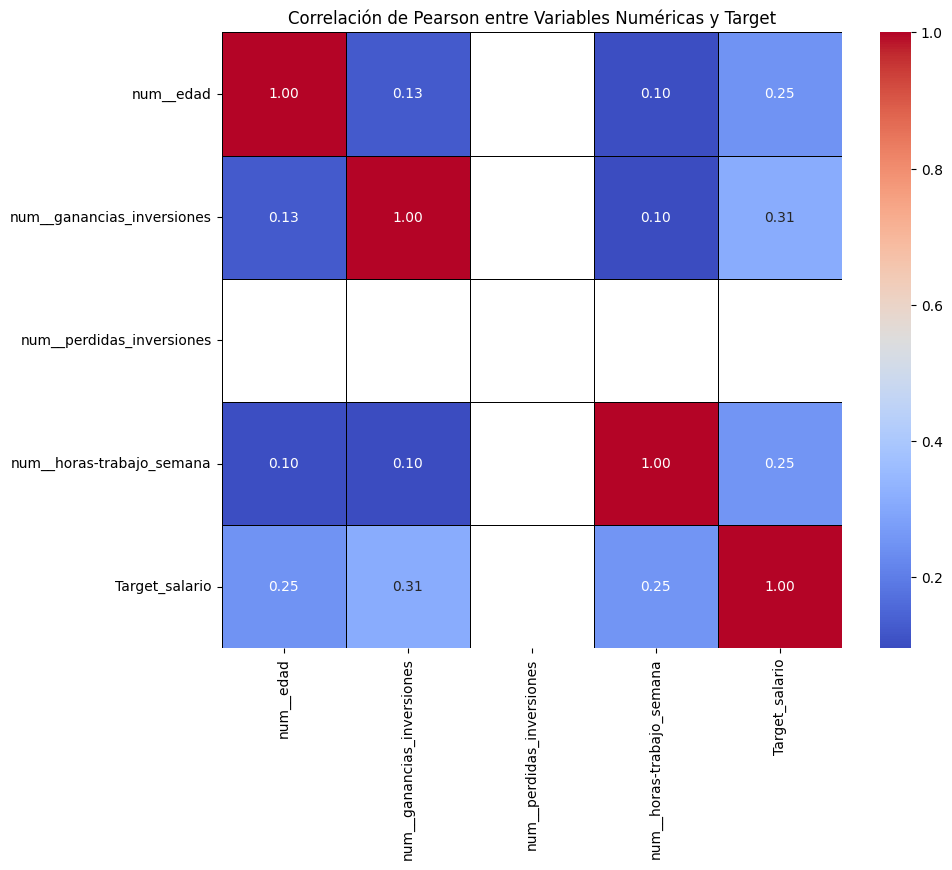

In [ ]:
# 'num_cols' contiene los nombres de tus columnas numéricas.
num_cols = [c for c in X_train_processed_df.columns if c.startswith("num__")]
print("Generando Heatmap de Correlación Numérica...")

# Crear un DataFrame para el análisis de correlación, incluyendo el Target
# Esto asume que y_train está alineado con X_train_processed_df
df_corr = X_train_processed_df[num_cols].copy()
df_corr['Target_salario'] = y_train 

# Calcular la matriz de correlación (Pearson)
corr_matrix = df_corr.corr()

# Graficar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    linecolor='black'
)
plt.title('Correlación de Pearson entre Variables Numéricas y Target')
plt.show()

En este punto nos damos cuenta de que algo pasa con la columna 'num__perdidas_inversiones' ya que todas sus correlaciones con el resto de columnas es nan (su varianza es 0 porque sus datos son muy dispersos y la mayoría (+25000) son 0 -> lo mismo pasa con num__ganancias_inversiones)

In [28]:
# Crear el DataFrame de correlación incluyendo solo las dos variables
df_corr_specific = X_train_processed_df[['num__edad', 'num__perdidas_inversiones']].copy()

# Calcular la matriz de correlación
corr_matrix_specific = df_corr_specific.corr()

# Acceder al valor numérico específico
correlacion = corr_matrix_specific.loc['num__perdidas_inversiones', 'num__edad']

print(f"El valor numérico de la correlación es: {correlacion:.6f}")
print("Varianza de num__edad:", X_train_processed_df['num__edad'].var())
print("Varianza de num__perdidas_inversiones:", X_train_processed_df['num__perdidas_inversiones'].var())

El valor numérico de la correlación es: nan
Varianza de num__edad: 164.556418773047
Varianza de num__perdidas_inversiones: 0.0


### DESBALANCEO DE CLASES

In [29]:
# Verificar el desbalance de clases en la variable objetivo
class_counts = df['salario'].value_counts(normalize=True) * 100

print("\n Distribución de la clase 'salario' ")
print(class_counts)

# Si el desbalance es significativo (ej. una clase es < 25%), 
# consideraremos técnicas como SMOTE, sobre/submuestreo, o ajustes 
# en los pesos de clase (class_weight) del modelo.


 Distribución de la clase 'salario' 
salario
<=50K    76.041146
>50K     23.958854
Name: proportion, dtype: float64


Una clase conforma el 24% del total (que es menor que el 25%). Por tanto, vamos a aplicar el sobremuestreo/oversampling:

El sobremuestreo/undersampling solo se hace sobre train para no sesgar la evaluación ni crear datos nuevos en test. Tenemos dos opciones para oversampling: SMOTE y RandomOverSampler. RandomOverSampler duplica aleatoriamente muestras de la clase minoritaria, mientras que SMOTE genera nuevas muestras sintéticas interpolando entre las existentes. Podemos usar cualquiera de los dos métodos, pero SMOTE suele ser preferido ya que introduce más diversidad en los datos sintéticos generados. Además, SMOTE puede ayudar a reducir el sobreajuste al crear nuevas muestras en lugar de simplemente duplicar las existentes. Por tanto, usaremos SMOTE para el sobremuestreo en este caso.

In [ ]:
# Usando SMOTE (se aplica sobre datos ya one-hot)
# Funciona así:
# 1. Elige una muestra de la clase minoritaria.
# 2. Encuentra a sus "vecinos" más cercanos (otras muestras minoritarias).
# 3. Crea una nueva muestra sintética en un punto aleatorio entre la muestra original y uno de sus vecinos.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed_df, y_train)
print("Tras SMOTE:", Counter(y_train_smote))

Tras SMOTE: Counter({0: 17032, 1: 17032})


In [31]:
X_train_bal, y_train_bal = X_train_smote, y_train_smote

No usamos **undersampling** porque en nuestro caso la clase mayoritaria representa ~76% y la minoritaria ~24%. Recortar la mayoritaria para equilibrar implicaría: descartar mucha información (perder variabilidad y patrones) y degradar la generalización, volviendo al modelo inestable.

Además, con muchas variables categóricas (tras one-hot), técnicas de **undersampling** pueden eliminar ejemplos útiles cerca de la frontera.

Como no tenemos un problema de coste computacional, preferimos **oversampling** (RandomOverSampler/SMOTE), que conservan todos los datos y equilibran el aprendizaje sin sacrificar información.

In [32]:
X_train_bal.head()

,num__edad,num__ganancias_inversiones,num__perdidas_inversiones,num__horas-trabajo_semana,cat__tipo_trabajo_Federal-gov,cat__tipo_trabajo_Local-gov,cat__tipo_trabajo_Never-worked,cat__tipo_trabajo_Private,cat__tipo_trabajo_Self-emp-inc,cat__tipo_trabajo_Self-emp-not-inc,...,cat__pais-origen_Portugal,cat__pais-origen_Puerto-Rico,cat__pais-origen_Scotland,cat__pais-origen_South,cat__pais-origen_Taiwan,cat__pais-origen_Thailand,cat__pais-origen_Trinadad&Tobago,cat__pais-origen_United-States,cat__pais-origen_Vietnam,cat__pais-origen_Yugoslavia
0,50.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,56.0,4874.9,0.0,50.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23.0,0.0,0.0,48.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,30.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [33]:
y_train_bal

array([0, 1, 0, ..., 1, 1, 1])

### SELECCION DE CARACTERÍSTICAS

Tal y cómo vemos en los resultados de la selección de características del preprocess.ipynb, el mejor modelo para la selección de características para la métrica F1 es RFECV con Regresión Logística (elegimos este modelo base), que es un modelo wrapper.

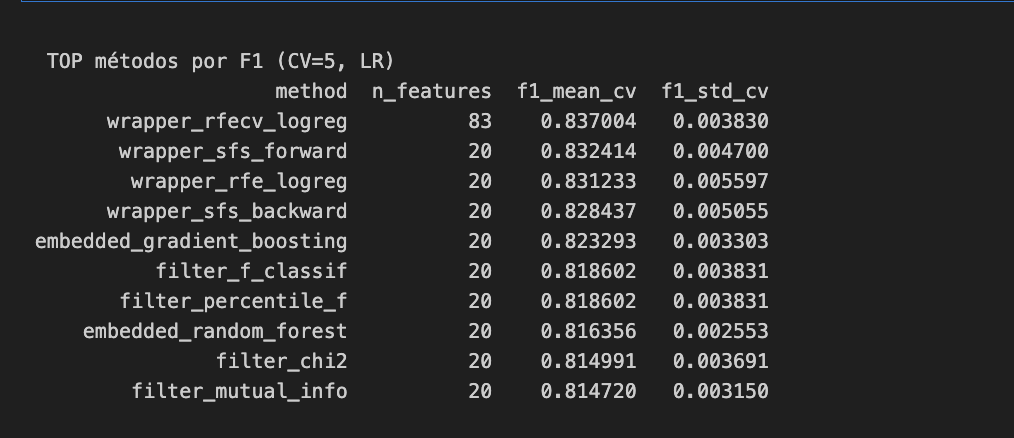

El ganador en la selección de features es el método RFECV con Regresión Logística (RL).

Este método es el mejor para nuestra tarea:

Es un Wrapper: Obliga a la Regresión Logística (RL) a entrenar repetidamente. En cada paso, elimina la feature que menos le ayuda a la RL, y se queda solo con las que de verdad mejoran el rendimiento.

Optimiza la Métrica F1-score: Lo hace fijándose siempre en el F1-score (la métrica utilizada en la competición) y usando Validación Cruzada (CV), así que la selección ya viene optimizada para obtener mejor F1-score.

Como entrena al modelo, es el único que tiene en cuenta cómo interaccionan las features entre sí (sobre todo las 80+ dummies OHE).

Por tanto, elegimos el RFECV por ser el que mejor sabe qué features necesita la RL para sacarle el máximo provecho a F1-score.

In [ ]:
X_train_bal = pd.DataFrame(X_train_smote, columns=feature_names)
y_train_bal = pd.Series(y_train_smote, name="salario_encoded")


X_test_df = X_test_processed_df.copy()   # test preprocesado
K = 20                                    # nº de atributos a seleccionar elegido

# Conjuntos de datos auxiliares según método
# Para wrappers/embebidos lineales conviene estandarizar
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_bal)

# modelo de evaluación rápida (F1)
base_clf = LogisticRegression(max_iter=2000, solver="liblinear") 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

def eval_set(feature_list, X_src, y=y_train_bal, clf=base_clf, label=""):
    """Valida por CV=5 con F1 usando solo las columnas seleccionadas."""
    if isinstance(X_src, np.ndarray):
        X_sel = X_src[:, [X_train_bal.columns.get_loc(c) for c in feature_list]]
    else:
        X_sel = X_src[feature_list].values
    scores = cross_val_score(clf, X_sel, y, scoring=f1, cv=cv, n_jobs=-1)
    return scores.mean(), scores.std()

#  Selecciones 
selected = {}  


rfecv_lr = RFECV(
    estimator=LogisticRegression(max_iter=3000, solver="liblinear"),
    step=max(1, X_train_bal.shape[1] // 10),
    cv=cv, scoring="f1", n_jobs=-1
)
rfecv_lr.fit(X_train_std, y_train_bal)
selected["wrapper_rfecv_logreg"] = X_train_bal.columns[rfecv_lr.support_].tolist()

In [ ]:
# SELECCIÓN FINAL (RFECV LR) 

# Creamos nuevos DataFrames/Series para el train balanceado. Así trabajamos sobre objetos distintos del array original de SMOTE.
X_train_bal_df     = pd.DataFrame(X_train_smote, columns=feature_names)  # train balanceado (SMOTE)
y_train_bal_series = pd.Series(y_train_smote, name="salario_encoded")

#Hacemos copias explícitas para evitar mutar los originales cuando escalo o selecciono features.
X_valid_df   = X_test_processed_df.copy()   # el "test" interno del split (validación)
X_kaggle_df  = X_test_kaggle_df.copy()      # test externo (salario_test.csv)


# Estandarizar solo las columnas numéricas (dejamos OHE 0/1 tal cual)
num_cols_ohe = [c for c in feature_names if c.startswith("num__")]
scaler_num = StandardScaler()
if num_cols_ohe:
    X_train_bal_df[num_cols_ohe] = scaler_num.fit_transform(X_train_bal_df[num_cols_ohe])
    X_valid_df[num_cols_ohe]     = scaler_num.transform(X_valid_df[num_cols_ohe])
    X_kaggle_df[num_cols_ohe]    = scaler_num.transform(X_kaggle_df[num_cols_ohe])

# RFECV con Regresión Logística (optimiza F1, CV=5)  (ajuste solo con train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv_lr = RFECV(
    estimator=LogisticRegression(max_iter=8000, solver="liblinear"),
    step=max(1, X_train_bal_df.shape[1] // 10),
    cv=cv, scoring="f1", n_jobs=-1,
    min_features_to_select=20
)
rfecv_lr.fit(X_train_bal_df.values, y_train_bal_series.values)

# Máscara y listas de columnas
mask = rfecv_lr.support_
selected_features = [col for col, keep in zip(X_train_bal_df.columns, mask) if keep]
print(f"RFECV ha seleccionado {len(selected_features)} variables.")
print("Ejemplo:", selected_features[:10])

# Proyectar a ese subconjunto (no hay fit en valid ni en salario_test de kaggle)
X_train_final  = X_train_bal_df[selected_features].copy()
X_valid_final  = X_valid_df[selected_features].copy()
X_kaggle_final = X_kaggle_df[selected_features].copy()

print("Shapes finales →",
      "train:", X_train_final.shape,
      "| valid:", X_valid_final.shape,
      "| kaggle:", X_kaggle_final.shape)


RFECV ha seleccionado 83 variables.
Ejemplo: ['num__edad', 'num__ganancias_inversiones', 'num__horas-trabajo_semana', 'cat__tipo_trabajo_Federal-gov', 'cat__tipo_trabajo_Local-gov', 'cat__tipo_trabajo_Self-emp-not-inc', 'cat__tipo_trabajo_State-gov', 'cat__tipo_trabajo_Without-pay', 'cat__estudios_10th', 'cat__estudios_11th']
Shapes finales → train: (34064, 83) | valid: (5600, 83) | kaggle: (4563, 83)


In [ ]:
# Requiere en memoria: 
#   X_train_processed_df, X_test_processed_df, X_test_kaggle_df,
#   y_train, y_test, le, selected_features (si USE_RFECV=True)

USE_RFECV = True  # True: usa RFECV-LR; False: OHE completo

# Clases del LabelEncoder (para invertir predicciones)
label_classes = le.classes_.tolist()

if USE_RFECV:
    feature_set_name = "rfecv_lr"
    assert 'selected_features' in globals() and len(selected_features) > 0, \
        "Falta 'selected_features' entrenadas por RFECV."
    feature_cols = list(selected_features)
else:
    feature_set_name = "ohe_full"
    feature_cols = list(X_train_processed_df.columns)

# Particiones listas para modelado
X_train = X_train_processed_df[feature_cols].copy()
y_train = np.asarray(y_train).astype(int)

X_valid = X_test_processed_df[feature_cols].copy()
y_valid = np.asarray(y_test).astype(int)

X_kaggle = X_test_kaggle_df[feature_cols].copy()
ids_kaggle = ids_test.copy() if 'ids_test' in globals() else None

# Columnas numéricas a escalar (para el pipeline después)
num_cols = [c for c in feature_cols if c.startswith("num__")]

print(f"Dataset: {feature_set_name} | "
      f"X_train={X_train.shape}, X_valid={X_valid.shape}, X_kaggle={X_kaggle.shape}")
print(f"Numéricas a escalar: {len(num_cols)}")


Dataset: rfecv_lr | X_train=(22398, 83), X_valid=(5600, 83), X_kaggle=(4563, 83)
Numéricas a escalar: 3


In [ ]:
# Escalado (preproceso) + evaluación
def make_prep(scaling: str = "standard", poly_degree: int = None):
    if not num_cols:
        return "passthrough"

    if scaling == "standard":
        scaler = StandardScaler()
    elif scaling == "minmax":
        scaler = MinMaxScaler()
    elif scaling == "none":
        scaler = FunctionTransformer(lambda X: X)
    else:
        raise ValueError("scaling no reconocido")

    steps = []
    if poly_degree is not None:
        steps.append(("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)))
    steps.append(("scaler", scaler))

    num_pipe = Pipeline(steps)
    prep = ColumnTransformer(
        transformers=[("num", num_pipe, num_cols)],
        remainder="passthrough"
    )
    return prep

def summarize_valid(estimator, Xva, yva, label_classes):
    y_pred = estimator.predict(Xva)

    y_score = None
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(Xva)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(Xva)

    out = {
        "valid_f1": f1_score(yva, y_pred),
        "valid_precision": precision_score(yva, y_pred),
        "valid_recall": recall_score(yva, y_pred),
        "valid_accuracy": accuracy_score(yva, y_pred),
        "valid_mcc": matthews_corrcoef(yva, y_pred),
        "valid_roc_auc": (roc_auc_score(yva, y_score) if y_score is not None else np.nan),
        "valid_pr_auc": (average_precision_score(yva, y_score) if y_score is not None else np.nan),
        "report": classification_report(yva, y_pred, target_names=label_classes, digits=4),
        "confusion_matrix": confusion_matrix(yva, y_pred)
    }
    return out

### Funciones para graficar (igual que en supervised.ipynb)

In [38]:
def plot_feature_importance_final(estimator, feature_names, n_top=10, model_name="Modelo"):
    """
    Calcula y grafica la importancia de las N features más relevantes para modelos 
    lineales (magnitud de coeficientes) y basados en árboles.
    """
    
    # Intentar acceder al clasificador dentro del pipeline
    classifier = estimator.named_steps.get('clf')
    
    # Modelos Lineales (LogisticRegression, SGDClassifier)
    if hasattr(classifier, 'coef_'):
        # Coeficientes para clasificación binaria (solo 1 fila)
        coef = classifier.coef_[0] if classifier.coef_.ndim > 1 else classifier.coef_
        importance = np.abs(coef)
        title = f"Magnitud de Coeficientes (Top {n_top}) - {model_name}"
        
    # Modelos Basados en Árboles/Ensembles (DecisionTree, RandomForest) -
    elif hasattr(classifier, 'feature_importances_'):
        importance = classifier.feature_importances_
        title = f"Importancia de Características (Top {n_top}) - {model_name}"
        
    else:
        print(f"No se puede calcular la importancia para {model_name}.")
        return

    # Si la transformación Polinomial se ejecutó, el número de features puede variar.
    # Debemos manejar la alineación de nombres.
    
    # Si el número de importancias es mayor que el número de features iniciales,
    # asumimos que hubo transformación (ej., PolinomialFeatures) y simplificamos los nombres.
    if len(importance) != len(feature_names):
        print("Advertencia: Se detectó transformación Polinomial o similar. Usando nombres genéricos.")
        # Generar nombres de features genéricos para el plot
        feature_names_plot = [f'Feature_{i}' for i in range(len(importance))]
    else:
        feature_names_plot = feature_names


    # Crear Series para ordenar
    feature_importance_series = pd.Series(importance, index=feature_names_plot)
    
    # Obtener las N más importantes
    top_features = feature_importance_series.nlargest(n_top)
    
    # Graficar
    plt.figure(figsize=(10, 6))
    top_features.sort_values(ascending=True).plot(kind='barh', color='darkred')
    plt.title(title)
    plt.xlabel('Importancia / Magnitud')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    
# Función Auxiliar para Obtener Scores 
def _get_model_scores(estimator, X_val):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_val)[:, 1]
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_val)
    return None

# Función Principal que genera Fila de 3 Gráficas
def plot_model_summary(estimator, X_val, y_val, class_names, model_name):
    
    # Predecir etiquetas y obtener scores
    y_pred = estimator.predict(X_val)
    y_score = _get_model_scores(estimator, X_val)
    
    # Configurar la Figura (1 fila, 3 columnas)
    # El tamaño 18x5 es bueno para 3 gráficas en una fila.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Rendimiento del Modelo: {model_name}', fontsize=16)

    
    # Subgráfico 1: matriz de confusión
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, linewidths=.5, cbar=False
    )
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_ylabel('Etiqueta Verdadera')
    axes[0].set_xlabel('Etiqueta Predicha')

    
    # Subgráfico 2: curva ROC
    
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_val, y_score)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                     label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_title('Curva ROC')
        axes[1].set_xlabel('FPR')
        axes[1].set_ylabel('TPR')
        axes[1].legend(loc="lower right")
    else:
        axes[1].set_title('Curva ROC (No disponible)')


    # Subgráfico 3: curva PRECISION-RECALL (PR)

    if y_score is not None:
        precision, recall, _ = precision_recall_curve(y_val, y_score)
        avg_precision = average_precision_score(y_val, y_score)
        
        # Baseline
        baseline = len(y_val[y_val==1]) / len(y_val)
        axes[2].plot([0, 1], [baseline, baseline], linestyle='--', color='gray', label=f'Línea base ({baseline:.2f})')
        
        axes[2].plot(recall, precision, color='purple', lw=2, 
                     label=f'PR-AUC = {avg_precision:.4f}')
        axes[2].set_title('Curva Precision-Recall')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].legend(loc="lower left")
    else:
        axes[2].set_title('Curva PR (No disponible)')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título principal quepa
    plt.show()

def plot_confusion_matrix(cm, class_names, title='Matriz de Confusión'):
    """
    Grafica la matriz de confusión como un mapa de calor (heatmap).
    
    Args:
        cm (np.ndarray): La matriz de confusión (e.g., de sklearn.metrics.confusion_matrix).
        class_names (list): Nombres de las clases (e.g., ['<=50K', '>50K']).
        title (str): Título de la gráfica.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True,        # Muestra los valores de cada celda
        fmt='d',           # Formato decimal 
        cmap='Blues',      # Esquema de color azulado
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=.5,     # Líneas separadoras
        cbar=False         # No muestra la barra de color
    )
    plt.title(title)
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.show()

En "supervised.ipynb" hemos comparado varios modelos y, **en el conjunto de validación**, el mejor **F1** lo da **Random Forest (sin escalar)**: **0.701**.
Esto se debe a que consigue **buen recall (0.803)** sin hundir la **precisión (0.623)**, y ese equilibrio maximiza F1. Los otros o bien suben mucho el recall pero bajan demasiado la precisión (logística/polinomial), o al revés (algunos SVM/MLP).

En números (validación):

* **F1:** RF 0.701 (**Top 1**). SVM RBF 0.694.
* **MCC:** RF 0.600 (**Top 1**), mejor correlación global.
* **Accuracy:** RF 0.836 (**Top 1**).
* **PR-AUC:** RF 0.772 (top-2, a ~0.002 del mejor).
* **ROC-AUC:** RF 0.913 (top-2, a ~0.0004 del mejor).

El modelo Random Forest es muy efectivo para nuestro problema de clasificación por los siguientes motivos. En primer lugar, su naturaleza se basa en árboles, permitiéndole capturar relaciones no lineales y combinaciones complejas de variables sin tener que realizar ingeniería de features extra. Además, es un algoritmo inherentemente robusto al escalado y a los outliers, ya que no depende de un preprocesamiento fino de los datos numéricos, lo que contribuye a reducir la varianza fuera de la validación cruzada. Finalmente, su diseño como método ensamblado funciona promediando las predicciones de múltiples árboles, lo que resulta en una menor varianza general y una mejor capacidad de generalización. Todo esto lo hace especialmente adecuado para nuestro problema de clase desbalanceada, donde logra mantener un recall alto con una precisión razonable, optimizando directamente el F1-score.

Aunque **SVM RBF** obtuvo en **CV (F1≈0.876)** un cifra más alta, en validación obtuvo solamente 0.694; parece tener sensibilidad. El RF fue **más estable** al cambiar de CV a validación.


Aquí se define (no se entrena aún) el pipeline y el grid de hiperparámetros para el modelo Random Forest (sin escalar).

In [39]:
#MEJOR MODELO: Random Forest (sin escalado), según valid_f1 
models = {}

pipe_rf_best = ImbPipeline([
    ("prep", make_prep()),  #sin escalado, ya uqe no se le pasa un argumento a la función de make_prep definida arriba
    ("smote", SMOTE(random_state=SEED)), 
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=5,
        class_weight={0: 1.25, 1: 1.0},
        random_state=SEED,
        n_jobs=-1
    ))
])

# Grid mínimo: fijado a los mejores hiperparámetros (1 sola combinación)
grid_rf_best = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__n_estimators": [100, 200], # número de árboles
    "clf__max_depth": [10, 16],
    "clf__min_samples_leaf": [5, 10],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}],
}

models["random_forest_unscaled"] = (pipe_rf_best, grid_rf_best)


Grid Search CV con 5 folds y F1 como métrica. Aplicado a Random Forest sin escalado.


 RANDOM_FOREST_UNSCALED | dataset=LR_UNSCALED


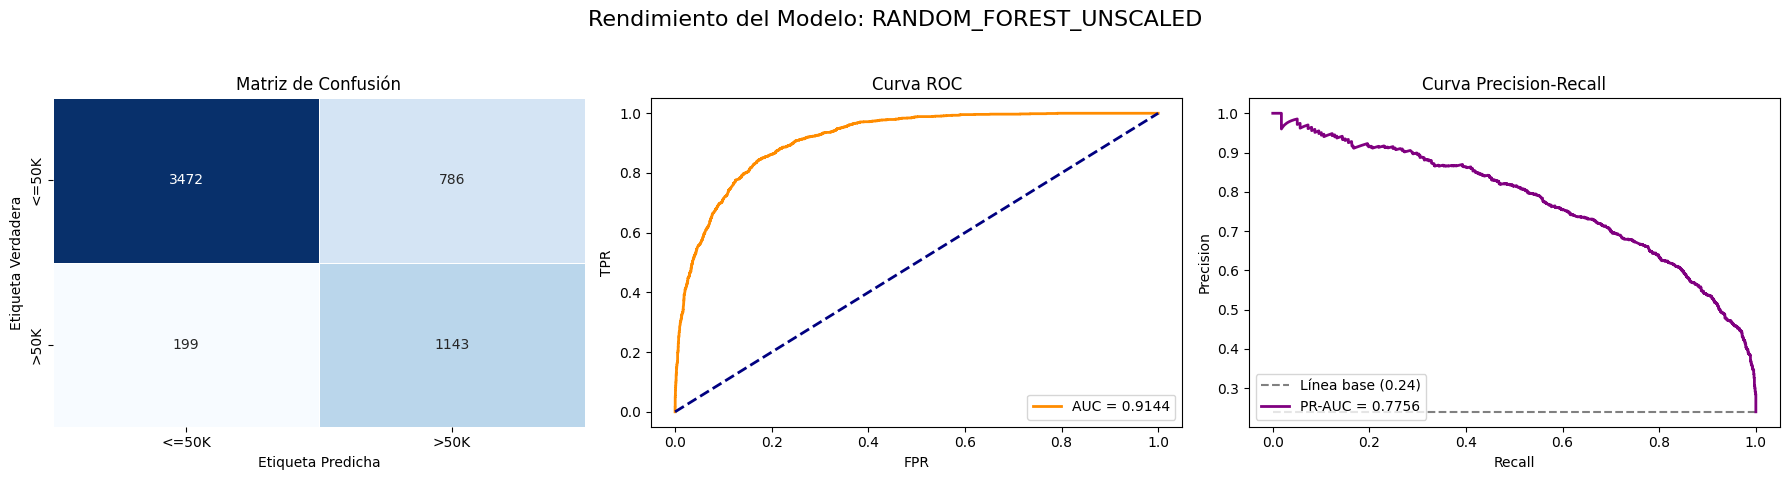

,model,best_params,cv_f1,cv_precision,cv_recall,cv_accuracy,cv_roc_auc,cv_pr_auc,valid_f1,valid_precision,valid_recall,valid_accuracy,valid_mcc,valid_roc_auc,valid_pr_auc
0,random_forest_unscaled,"{'clf__class_weight': {0: 1.25, 1: 1.0}, 'clf_...",0.68075,0.57927,0.825567,0.814448,0.904084,0.753824,0.698869,0.592535,0.851714,0.824107,0.599273,0.914392,0.775574


In [40]:
X_train_ds, y_train_ds = X_train, y_train
X_valid_ds, y_valid_ds = X_valid, y_valid
dataset_label = "LR_UNSCALED"  

all_rows = []
best_estimators = {}

for key, (pipe, grid) in models.items():
    print(f"\n {key.upper()} | dataset={dataset_label}")

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=SCORINGS,
        refit=REFIT,
        cv=CV,
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )
    gs.fit(X_train_ds, y_train_ds)
    best = gs.best_estimator_
    best_estimators[key] = best

    idx = gs.best_index_
    row = {
        "model": key,
        "best_params": gs.best_params_,
        "cv_f1": gs.cv_results_["mean_test_f1"][idx],
        "cv_precision": gs.cv_results_["mean_test_precision"][idx],
        "cv_recall": gs.cv_results_["mean_test_recall"][idx],
        "cv_accuracy": gs.cv_results_["mean_test_accuracy"][idx],
        "cv_roc_auc": gs.cv_results_["mean_test_roc_auc"][idx],
        "cv_pr_auc": gs.cv_results_["mean_test_average_precision"][idx],
    }

    val_metrics = summarize_valid(best, X_valid_ds, y_valid_ds, label_classes)
    row.update({
        "valid_f1": val_metrics["valid_f1"],
        "valid_precision": val_metrics["valid_precision"],
        "valid_recall": val_metrics["valid_recall"],
        "valid_accuracy": val_metrics["valid_accuracy"],
        "valid_mcc": val_metrics["valid_mcc"],
        "valid_roc_auc": val_metrics["valid_roc_auc"],
        "valid_pr_auc": val_metrics["valid_pr_auc"],
    })
    all_rows.append(row)

    plot_model_summary(
        estimator=best,
        X_val=X_valid_ds,
        y_val=y_valid_ds,
        class_names=label_classes,
        model_name=key.upper()
    )

results_df = pd.DataFrame(all_rows).sort_values("valid_f1", ascending=False).reset_index(drop=True)
results_df


 Mejor configuración (VALID) 
model: random_forest_unscaled
best_params: {'clf__class_weight': {0: 1.25, 1: 1.0}, 'clf__max_depth': 16, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'smote': SMOTE(k_neighbors=3, random_state=42)}


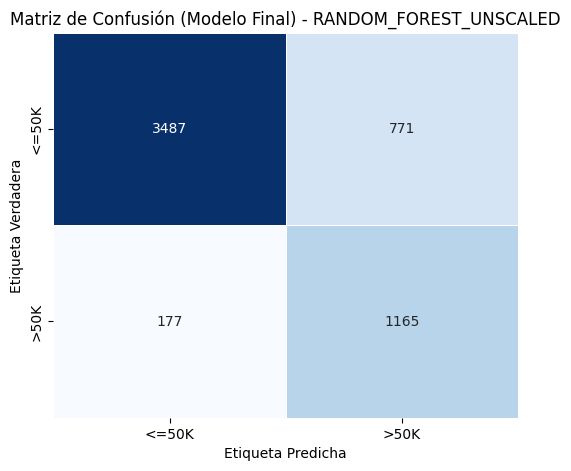

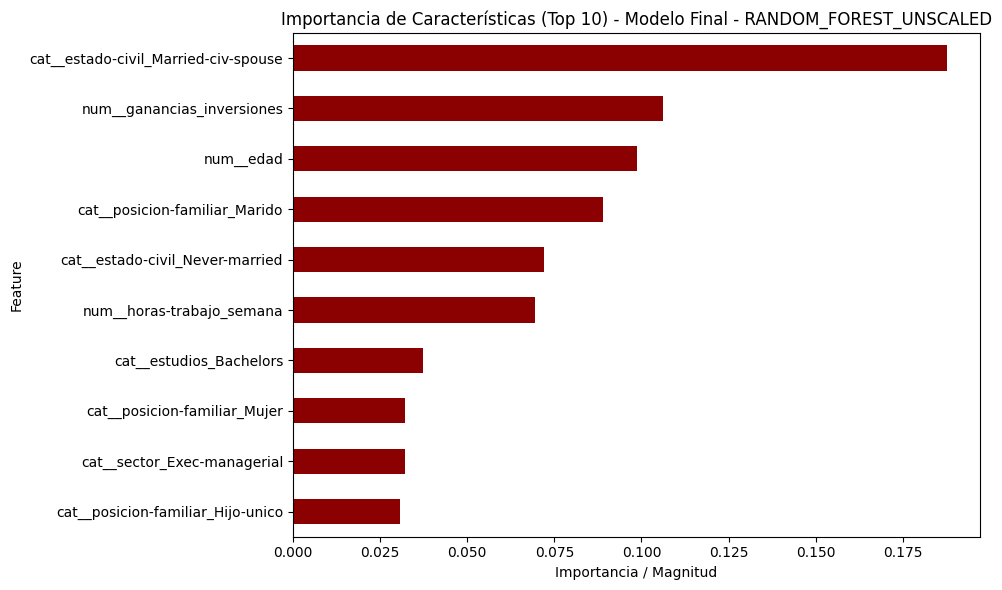

 Guardado: test_labels.csv
   ID salario
0   1   <=50K
1   2   <=50K
2   3   <=50K
3   4    >50K
4   5   <=50K
 Guardado: best_model.pkl y best_model_info.json
Guardado: model_search_results.csv


In [ ]:
# Elegir mejor modelo, refit en TRAIN+VALIDACIÓN, guardar mejor modelo y test_labels.csv 

best_row = results_df.loc[results_df["valid_f1"].idxmax()]
best_key      = best_row["model"]
best_params   = best_row["best_params"]

if isinstance(best_params, str):
    try:
        best_params = ast.literal_eval(best_params)
    except Exception:
        pass  # si ya es dict 

print(" Mejor configuración (VALID) ")
print("model:", best_key)
print("best_params:", best_params)

# Reentrenar el mejor en TRAIN+VALID (para usar todos los datos antes de predecir TEST)
X_all = pd.concat([X_train, X_valid], axis=0)
y_all = np.concatenate([y_train, y_valid], axis=0)

best_estimator = best_estimators[best_key]
best_estimator_all = clone(best_estimator)

# Asegurar hiperparámetros por si acaso
if isinstance(best_params, dict) and best_params:
    best_estimator_all.set_params(**best_params)

#  FIT final con todos los datos
best_estimator_all.fit(X_all, y_all)



# Matriz de Confusión (usando el modelo final en el conjunto de validación)
# Para la matriz, usamos el CM del resumen de validación, que es el que nos dio el mejor F1

y_valid_pred = best_estimator_all.predict(X_valid_ds)
cm_final = confusion_matrix(y_valid_ds, y_valid_pred)

# Llama a la función definida previamente:
plot_confusion_matrix(
    cm=cm_final, 
    class_names=label_classes, 
    title=f'Matriz de Confusión (Modelo Final) - {best_key.upper()}'
)

# 2. Importancia de Características
# Llama a la función definida previamente (le pasamos el modelo, la lista de features y el nombre)
plot_feature_importance_final(
    estimator=best_estimator_all, 
    feature_names=X_all.columns.tolist(),
    n_top=10, 
    model_name=f'Modelo Final - {best_key.upper()}'
)


# Predecir TEST externo y guardar como test_labels.csv
y_kaggle_enc = best_estimator_all.predict(X_kaggle)
idx_to_label = {i: cls for i, cls in enumerate(label_classes)}
y_kaggle_lab = pd.Series(y_kaggle_enc).map(idx_to_label).values

submission = pd.DataFrame({"ID": ids_kaggle, "salario": y_kaggle_lab})
submission.to_csv("test_labels.csv", index=False)
print(" Guardado: test_labels.csv")
print(submission.head())

# Guardar el mejor modelo (pickle sí soporta objetos complejos como SMOTE)
joblib.dump(best_estimator_all, "best_model.pkl")


# Convertimos los valores de los parámetros a String para que JSON no falle
if isinstance(best_params, dict):
    best_params_safe = {k: str(v) for k, v in best_params.items()}
else:
    best_params_safe = str(best_params)

with open("best_model_info.json", "w") as f:
    json.dump({
        "model": best_key,
        "best_params": best_params_safe,  # Usamos la versión convertida a texto
        "valid_f1": float(best_row["valid_f1"]),
        "valid_accuracy": float(best_row["valid_accuracy"]),
        "cv_f1": float(best_row.get("cv_f1", np.nan)),
        "cv_accuracy": float(best_row.get("cv_accuracy", np.nan)),
        "feature_set": feature_set_name  # "rfecv_lr" u "ohe_full"
    }, f, indent=2)
print(" Guardado: best_model.pkl y best_model_info.json")

# Guardar ranking completo
results_df.to_csv("model_search_results.csv", index=False)
print("Guardado: model_search_results.csv")